Epoch [1/5], Loss: 0.1539
Epoch [2/5], Loss: 0.0451
Epoch [3/5], Loss: 0.0320
Epoch [4/5], Loss: 0.0235
Epoch [5/5], Loss: 0.0178

Test Accuracy: 99.16%


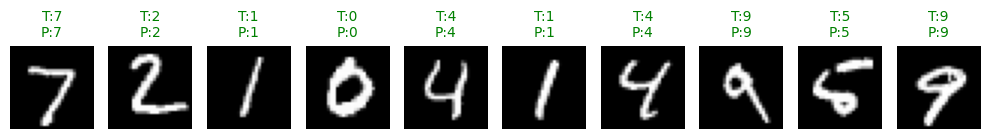

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ---------------------------------------------
# CNN Model Definition
# ---------------------------------------------
class CNNModel(nn.Module):
    def __init__(self, epochs=5):
        super(CNNModel, self).__init__()
        self.epochs = epochs

        # CNN layers with activation functions
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)  # 10 output classes for digits 0–9

    def forward(self, x):
        # Convolution + Activation + Pooling
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        # Flatten for fully connected layers
        x = x.view(-1, 64 * 7 * 7)

        # Fully connected + Activation
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

    # ---------------------------------------------
    # Training Loop
    # ---------------------------------------------
    def train_model(self, train_loader, optimizer, criterion, device):
        self.train()
        for epoch in range(self.epochs):
            running_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                # Forward pass
                outputs = self(images)
                loss = criterion(outputs, labels)

                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            print(f"Epoch [{epoch+1}/{self.epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # ---------------------------------------------
    # Evaluation (Accuracy)
    # ---------------------------------------------
    def evaluate_model(self, test_loader, device):
        self.eval()
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        all_images = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = self(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                # Store samples for visualization
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_images.extend(images.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"\nTest Accuracy: {accuracy:.2f}%")
        self.visualize_predictions(all_images, all_labels, all_preds)
        return accuracy

    # ---------------------------------------------
    # Visualization of Predictions
    # ---------------------------------------------
    def visualize_predictions(self, images, labels, preds, num_samples=10):
        plt.figure(figsize=(10, 2))
        for i in range(num_samples):
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(images[i][0], cmap='gray')
            color = 'green' if labels[i] == preds[i] else 'red'
            plt.title(f"T:{labels[i]}\nP:{preds[i]}", color=color, fontsize=10)
            plt.axis('off')
        plt.tight_layout()
        plt.show()

# ---------------------------------------------
# Main Execution
# ---------------------------------------------
if __name__ == "__main__":
    # Device configuration (GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Data transformation (normalization)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # Load datasets
    train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

    # Initialize model, loss, and optimizer
    model = CNNModel(epochs=5).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train and evaluate
    model.train_model(train_loader, optimizer, criterion, device)
    model.evaluate_model(test_loader, device)
